# NovaRetail+ — Customer Behavior Drivers of Annual Revenue

**A correlational analysis identifying which customer behavior signals are most strongly associated with revenue generation on a Latin American e-commerce platform.**


## Business Context

NovaRetail+ is an e-commerce platform operating across Latin America with millions of active users. Heading into the close of 2024, the **Growth & Retention** team needs to answer one question:

> **Which customer behavior factors are most strongly associated with the annual revenue a customer generates?**

This is an exploratory, **correlational** analysis. Correlation does not imply causation — every finding below is framed accordingly, distinguishing between statistical association and business interpretation.


## 1. Data Loading & Exploration

We start by validating that the dataset loads correctly, checking data types, and scanning for missing values or out-of-range values. Before looking for correlations, we first need to understand the terrain.

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import pointbiserialr, chi2_contingency
import itertools


### Load dataset

In [2]:
# Load dataset and rename columns to English for readability
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')

df = df.rename(columns={
    'id_cliente': 'customer_id',
    'edad': 'age',
    'nivel_ingreso': 'income_level',
    'visitas_mes': 'monthly_visits',
    'compras_mes': 'monthly_purchases',
    'gasto_publicidad_dirigida': 'targeted_ad_spend',
    'satisfaccion': 'satisfaction_score',
    'miembro_premium': 'premium_member',
    'abandono': 'churned',
    'tipo_dispositivo': 'device_type',
    'region': 'region',
    'ingreso_anual': 'annual_revenue'
})

df['device_type'] = df['device_type'].replace({
    'móvil': 'Mobile', 'escritorio': 'Desktop', 'tablet': 'Tablet'
})
df['region'] = df['region'].replace({
    'norte': 'North', 'sur': 'South', 'oeste': 'West', 'este': 'East'
})

df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         15000 non-null  object 
 1   age                 15000 non-null  float64
 2   income_level        15000 non-null  float64
 3   monthly_visits      15000 non-null  int64  
 4   monthly_purchases   15000 non-null  int64  
 5   targeted_ad_spend   15000 non-null  float64
 6   satisfaction_score  15000 non-null  float64
 7   premium_member      15000 non-null  int64  
 8   churned             15000 non-null  int64  
 9   device_type         15000 non-null  object 
 10  region              15000 non-null  object 
 11  annual_revenue      15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


,age,income_level,monthly_visits,monthly_purchases,targeted_ad_spend,satisfaction_score,premium_member,churned,annual_revenue
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000


#### Dataset description

| Column | Description |
|---|---|
| `customer_id` | Unique customer identifier |
| `age` | Customer age |
| `income_level` | Estimated annual personal income |
| `monthly_visits` | App/website visits during the month |
| `monthly_purchases` | Number of purchases made during the month |
| `targeted_ad_spend` | Ad spend allocated to the user |
| `satisfaction_score` | Customer satisfaction rating (1–5) |
| `premium_member` | Whether the customer holds a premium subscription (1) or not (0) |
| `churned` | Whether the customer left the platform (1) or not (0) |
| `device_type` | Device used by the customer (Mobile, Desktop, Tablet) |
| `region` | Customer's geographic region (North, South, West, East) |
| `annual_revenue` | Annual revenue generated by the customer for the company |

The primary metric of interest is `annual_revenue`, used to evaluate the economic impact of each customer.


In [3]:
# Preview the first rows
df.head()


,customer_id,age,income_level,monthly_visits,monthly_purchases,targeted_ad_spend,satisfaction_score,premium_member,churned,device_type,region,annual_revenue
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,Mobile,North,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,Tablet,South,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,Mobile,East,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,Mobile,East,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,Mobile,South,33.76


## 2. Data Preparation & Assumptions

### Initial data exploration

The dataset contains **15,000 records** and **12 columns**, with no missing values.

**Numeric variables:** `age`, `income_level`, `monthly_visits`, `monthly_purchases`, `targeted_ad_spend`, `satisfaction_score`, `annual_revenue`.

Most of these columns have the appropriate data type. `age` is stored as a float (`float64`), although logically it should be an integer (`int64`). This doesn't affect the statistical calculations, but it's corrected below for consistency.

**Binary variables:** `premium_member`, `churned` — both encoded as 0/1, no further transformation needed.

**Categorical variables:** `customer_id`, `device_type`, `region` — correctly defined, no further transformation needed.


In [4]:
# Fix data type
df["age"] = df["age"].astype(int)


In [5]:
# Verify the change
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_id         15000 non-null  object 
 1   age                 15000 non-null  int64  
 2   income_level        15000 non-null  float64
 3   monthly_visits      15000 non-null  int64  
 4   monthly_purchases   15000 non-null  int64  
 5   targeted_ad_spend   15000 non-null  float64
 6   satisfaction_score  15000 non-null  float64
 7   premium_member      15000 non-null  int64  
 8   churned             15000 non-null  int64  
 9   device_type         15000 non-null  object 
 10  region              15000 non-null  object 
 11  annual_revenue      15000 non-null  float64
dtypes: float64(4), int64(5), object(3)
memory usage: 1.4+ MB


### Explore numeric variables

In [6]:
# Descriptive statistics for numeric variables
numeric_cols = ['age', 'income_level', 'monthly_visits', 'monthly_purchases',
                 'targeted_ad_spend', 'satisfaction_score', 'annual_revenue']
print(df[numeric_cols].describe())


                age  income_level  monthly_visits  monthly_purchases  \
count  15000.000000  15000.000000    15000.000000       15000.000000   
mean      38.262400  30019.704782       10.029000           1.206467   
std       11.492378   9833.166305        3.158189           1.105284   
min       18.000000   8000.000000        1.000000           0.000000   
25%       30.000000  23127.097500        8.000000           0.000000   
50%       38.000000  30023.745000       10.000000           1.000000   
75%       46.000000  36768.440000       12.000000           2.000000   
max       75.000000  74790.840000       25.000000           8.000000   

       targeted_ad_spend  satisfaction_score  annual_revenue  
count       15000.000000        15000.000000    15000.000000  
mean           20.149301            3.603693       36.594180  
std            10.880724            0.685300       34.484888  
min             0.000000            1.000000        0.000000  
25%            12.310000            

**Observations**

- `age`: Symmetric distribution, mean of 38.2 years, spanning a wide adult range from 18 to 75.
- `income_level`: Mean of 30,019 vs. median of 30,023 — very homogeneous and centered around 30,000, with no visible anomalies. The distribution is highly symmetric.
- `monthly_visits`: Consistent activity, with a median of 10 visits per month and a maximum of 25; also fairly symmetric.
- `monthly_purchases`: 25% of users make no purchases in a given month, reflecting a significant share of transactionally inactive users. Most of the user base buys little or nothing, while a small, select group sustains most of the platform's transactional activity.
- `targeted_ad_spend`: Average investment of 20.14 per user, up to a maximum of 75.51. A minimum of 0 means some users received no ad budget at all — this group can act as a natural control, allowing us to compare zero-spend vs. positive-spend users to test whether advertising is actually associated with higher revenue.
- `satisfaction_score`: Centered at 3.6, indicating a medium-to-high general perception — an acceptable user experience with room for improvement.
- `annual_revenue`: Clear right skew (mean 36.59 > median 30.70) driven by a group of high-value customers generating up to 244.69, while 25% of the base generates no revenue at all (0). A select group of high-value customers spends far more than the average user and pulls the mean upward.


### Explore binary variables

In [7]:
# Check that each column only contains two possible values, as proportions
binary_cols = ['premium_member', 'churned']
print(df[binary_cols].mean().rename('share_of_1').to_frame())
print(df[binary_cols].apply(pd.Series.value_counts))


                share_of_1
premium_member    0.139267
churned           0.150733
   premium_member  churned
0           12911    12739
1            2089     2261


**Observations**

- `premium_member`: Clean binary variable (verified to contain only 0/1 values). Only **13.93%** of the customer base holds an active premium subscription — the base is overwhelmingly composed of standard users.
- `churned`: Also clean and validated. Churn rate of **15.07%** — slightly higher than the premium share, highlighting an immediate retention challenge for the Growth team.


### Explore categorical variables

In [8]:
# Check the number of unique values per categorical variable
categorical_cols = ['customer_id', 'device_type', 'region']
df[categorical_cols].describe()


,customer_id,device_type,region
count,15000,15000,15000
unique,15000,3,4
top,CL-105854,Mobile,North
freq,1,9818,4395


In [9]:
# Explore categorical distributions
df[['device_type']].value_counts(normalize=True)


device_type
Mobile         0.654533
Desktop        0.248000
Tablet         0.097467
dtype: float64

In [10]:
df[['region']].value_counts(normalize=True)


region
North     0.2930
West      0.2540
South     0.2484
East      0.2046
dtype: float64

**Observations**

- `device_type`: Clean categorical variable showing a clear dominance of mobile traffic, accounting for **65.45%** of platform users. This makes mobile app/interface optimization a business priority.
- `region`: A fairly homogeneous, balanced geographic distribution across Latin America. **North** is subtly the largest market (29.3% of customers), while **East** has the smallest share (20.46%).


### Assumptions

- The analysis uses the **full available dataset**.
- Data contains no errors and is correctly typed.
- Different coefficients are used depending on variable type:
  - **Pearson** assumes linear relationships between numeric variables.
  - **Spearman** evaluates monotonic relationships and does not require normality.
  - **Point-biserial** is used for numeric–binary relationships.
  - **Cramér's V** is used for associations between categorical variables.

**Core assumption:** this analysis identifies associations between variables or segments — it does not test causality.


## 3. Visual Exploration of Relationships

### Correlation heatmap

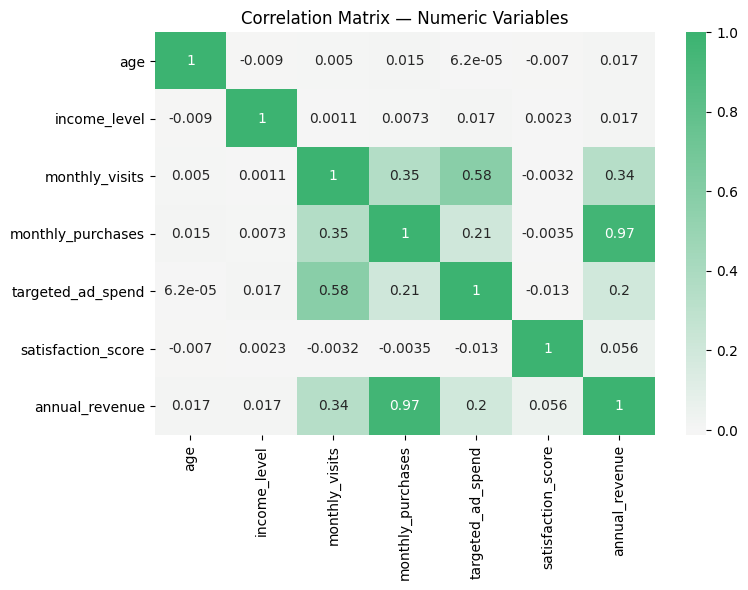

In [11]:
# Visualize the correlation matrix to identify relationships
df_corr = df[numeric_cols].corr()
custom_cmap = LinearSegmentedColormap.from_list("custom_colors", ["peachpuff", "whitesmoke", "mediumseagreen"])

plt.figure(figsize=(8, 6))
sns.heatmap(df_corr, annot=True, cmap=custom_cmap, center=0)
plt.title('Correlation Matrix — Numeric Variables')
plt.tight_layout()
plt.show()


**Observations**

- Most variable pairs show weak or near-zero correlations, indicating low linear association between them — in general, each variable contributes distinct information. A few pairs stand out with moderate-to-high correlations, especially `monthly_purchases` with `annual_revenue`, and `targeted_ad_spend` with `monthly_visits`.
- **Regarding `annual_revenue`:** `monthly_purchases` shows the strongest positive correlation with `annual_revenue` (r = 0.97), evidencing a very strong linear relationship between purchase frequency and revenue generated for NovaRetail+. `monthly_visits`, in contrast, shows a moderate correlation (r = 0.34) — more visits partially increase the likelihood of generating revenue, but don't guarantee conversion into purchases.
- `targeted_ad_spend` shows a weak positive correlation with `annual_revenue` (r = 0.20), while `age`, `income_level`, and `satisfaction_score` show practically null correlations. Within this dataset, purchase behavior explains revenue far better than demographic or economic customer characteristics.
- There's also a moderate correlation between `targeted_ad_spend` and `monthly_visits` (r = 0.58), suggesting higher ad investment is associated with increased platform traffic. This doesn't imply causation, and the value isn't high enough to signal a serious multicollinearity concern.


### Scatterplots for key variable pairs

Based on the correlation matrix, a full pairwise scatterplot grid was skipped — most variables show no meaningful linear association, and a global grid would only add visual noise. Instead, we plot only the key pairs identified with moderate-to-strong relationships.

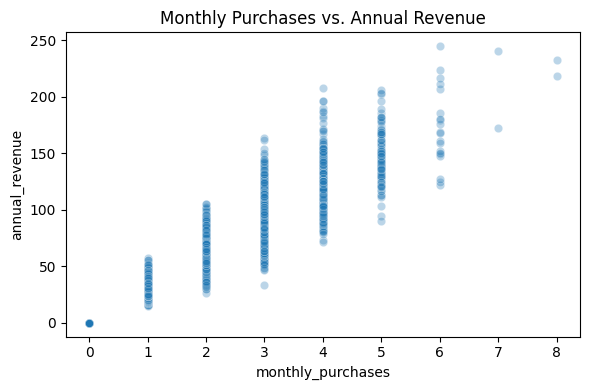

In [12]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_purchases', y='annual_revenue', alpha=0.3)
plt.title('Monthly Purchases vs. Annual Revenue')
plt.tight_layout()
plt.show()


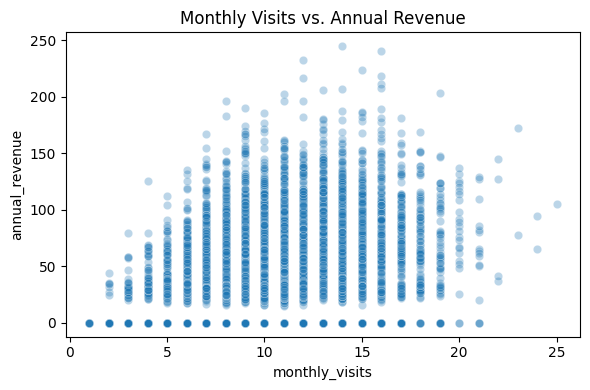

In [13]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='monthly_visits', y='annual_revenue', alpha=0.3)
plt.title('Monthly Visits vs. Annual Revenue')
plt.tight_layout()
plt.show()


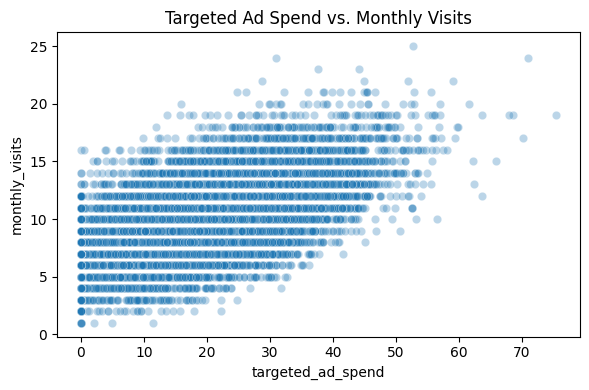

In [14]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='targeted_ad_spend', y='monthly_visits', alpha=0.3)
plt.title('Targeted Ad Spend vs. Monthly Visits')
plt.tight_layout()
plt.show()


**Observations**

**`monthly_purchases` vs. `annual_revenue`**
- Direction: positive and near-perfect.
- Spread: very low — points cluster into stepped vertical bands rising rigidly, consistent with r = 0.97.
- Outliers: no disruptive values outside the general pattern.
- Note: the stepped pattern reflects that `monthly_purchases` takes discrete integer values, which explains the vertical-band structure.

**`monthly_visits` vs. `annual_revenue`**
- Direction: positive but very faint.
- Spread: high — a diffuse, widely distributed cloud.
- Outliers: a large concentration of points at `annual_revenue` = 0 regardless of visit volume — traffic alone isn't associated with monetization.
- Note: the relationship is weak (r ≈ 0.34); visits are a necessary but not sufficient condition for generating revenue.

**`targeted_ad_spend` vs. `monthly_visits`**
- Direction: positive and moderate (r ≈ 0.58).
- Spread: medium — a visible upward, oval-shaped trend.
- Outliers: no disruptive extreme values identified.
- Note: profiles with higher targeted ad investment tend to associate with higher monthly visit volumes; this alignment is moderate and stays within correlational territory, without implying causation.


## 4. Statistical Evidence — Correlation Coefficients

This section reports the coefficients that support the patterns observed visually, using the method appropriate to each variable type.

### Pearson / Spearman

In [15]:
# Compute correlation between relevant variables
def numeric_corr(df, cols):
    pearson_corr = df[cols].corr(method='pearson')
    spearman_corr = df[cols].corr(method='spearman')

    print("Pearson correlation:")
    print(pearson_corr)
    print("\nSpearman correlation:")
    print(spearman_corr)

numeric_corr(df, numeric_cols)


Pearson correlation:
                         age  income_level  monthly_visits  monthly_purchases  \
age                 1.000000     -0.009003        0.004998           0.014971   
income_level       -0.009003      1.000000        0.001060           0.007309   
monthly_visits      0.004998      0.001060        1.000000           0.353844   
monthly_purchases   0.014971      0.007309        0.353844           1.000000   
targeted_ad_spend   0.000062      0.016834        0.578947           0.207528   
satisfaction_score -0.006963      0.002301       -0.003179          -0.003542   
annual_revenue      0.017496      0.017446        0.337147           0.967149   

                    targeted_ad_spend  satisfaction_score  annual_revenue  
age                          0.000062           -0.006963        0.017496  
income_level                 0.016834            0.002301        0.017446  
monthly_visits               0.578947           -0.003179        0.337147  
monthly_purchases         

**Observations**

**`monthly_purchases` vs. `annual_revenue`**

Positive and extremely strong correlation: 0.967 (Pearson) and 0.967 (Spearman). This near-exact match confirms the relationship is robust, linear, and monotonic, cementing purchase frequency as the factor most strongly associated with annual revenue.

**`targeted_ad_spend` vs. `monthly_visits`**

Positive and moderate correlation: 0.578 (Pearson) and 0.559 (Spearman). Since this is the highest correlation among independent variables, the risk of severe multicollinearity is low. If it became critical, `targeted_ad_spend` and `monthly_visits` would be the variables directly affected — a regression model would lose the ability to isolate each one's individual impact, inflating the standard errors of their coefficients and distorting their true importance when predicting `annual_revenue`.

**`monthly_visits` vs. `annual_revenue`**

Positive and moderate-to-weak correlation. Pearson's coefficient (0.337) is slightly higher than Spearman's (0.320). This small gap is explained by the right-skewed distribution of `annual_revenue` — customers with unusually high revenue exert a slight leverage effect on Pearson. Since the difference is under 0.02, the distribution shows no severe non-linear distortion, confirming a stable but limited linear association between traffic and monetization.


### Point-biserial correlation

In [16]:
# Compute correlation between binary variables and annual_revenue
for col in binary_cols:
    corr, pvalue = pointbiserialr(df[col], df['annual_revenue'])
    print(f"Variable: {col}")
    print(f"  Point-biserial correlation: {corr:.4f}")
    print(f"  p-value: {pvalue:.4e}")
    print("-" * 40)


Variable: premium_member
  Point-biserial correlation: 0.0931
  p-value: 3.0943e-30
----------------------------------------
Variable: churned
  Point-biserial correlation: -0.0028
  p-value: 7.2947e-01
----------------------------------------


**Observations**

**`premium_member` vs. `annual_revenue`**
- Direction: positive — premium customers tend to be associated with slightly higher annual revenue.
- Magnitude: low (0.0931) — the difference between groups exists but is weak; premium membership alone doesn't substantially explain revenue.
- Reliability: p-value is practically zero (3.09e-30), so this result is statistically significant and very unlikely to be due to chance — the association is real, but weak.

**`churned` vs. `annual_revenue`**
- Direction: negative — churned customers tend to be associated with slightly lower annual revenue.
- Magnitude: practically null (-0.0028) — no meaningful difference between churned and retained customers.
- Reliability: p-value is 0.73 (very high), so this result is **not** statistically significant — the observed correlation is indistinguishable from noise and shouldn't be interpreted as a real relationship.


### Cramér's V

In [17]:
# Function to compute Cramér's V
all_categorical = ['region', 'device_type', 'premium_member', 'churned']

def cramers_v(df, col1, col2):
    table = pd.crosstab(df[col1], df[col2])
    chi2, p_value, dof, expected = chi2_contingency(table)
    n = table.values.sum()
    coef_v = np.sqrt(chi2 / (n * (min(table.shape) - 1)))
    print(f"{col1} vs {col2}")
    print(f"  Cramer's V: {coef_v:.4f} | p-value: {p_value:.4e}")
    print("-" * 50)

print("=== CATEGORICAL ASSOCIATION MATRIX (CRAMER'S V) ===")
print("Interpretation: 0 = full independence | 1 = perfect association\n")

for col1, col2 in itertools.combinations(all_categorical, 2):
    cramers_v(df, col1, col2)


=== CATEGORICAL ASSOCIATION MATRIX (CRAMER'S V) ===
Interpretation: 0 = full independence | 1 = perfect association

region vs device_type
  Cramer's V: 0.0124 | p-value: 5.9648e-01
--------------------------------------------------
region vs premium_member
  Cramer's V: 0.0126 | p-value: 4.9893e-01
--------------------------------------------------
region vs churned
  Cramer's V: 0.0154 | p-value: 3.1165e-01
--------------------------------------------------
device_type vs premium_member
  Cramer's V: 0.0197 | p-value: 5.4031e-02
--------------------------------------------------
device_type vs churned
  Cramer's V: 0.0072 | p-value: 6.7456e-01
--------------------------------------------------
premium_member vs churned
  Cramer's V: 0.1202 | p-value: 4.5392e-49
--------------------------------------------------


**Observations**

**General pattern**

Most categorical variable pairs show very weak or virtually nonexistent associations. Pairs involving **region** and **device_type** score below **0.02**, with p-values above 0.05, so there isn't enough statistical evidence to reject independence. In practical terms, geographic location and device type don't meaningfully influence premium membership or churn.

**Case of interest: `device_type` vs. `premium_member`**

This pair shows a Cramér's V of **0.0197** and a p-value of **0.054** — right at the conventional 0.05 significance threshold. While this could hint at a slight tendency, the evidence isn't strong enough to claim a significant association; both variables are treated as independent within the scope of this analysis.

**Main finding: `premium_member` vs. `churned`**

This is the most relevant finding in the categorical matrix: Cramér's V of **0.1202** with a p-value of **4.54 × 10⁻⁴⁹**. The magnitude of the association is still **weak**, but the statistical evidence is very strong — this relationship is highly unlikely to be due to chance.

**Business interpretation**

The results suggest that **premium membership status** is associated with churn behavior, though this relationship alone explains only a small part of the phenomenon and doesn't imply causation. Churn likely depends on a combination of additional factors — satisfaction, purchase frequency, customer activity, and other behavioral variables.

**Conclusion**

Overall, categorical variables show limited power to explain customer behavior. The only statistically relevant association is between `premium_member` and `churned`, and even that is weak in intensity. Understanding churn will require integrating numeric variables and more advanced analytical models, rather than relying solely on relationships between categorical variables.


## 5. Key Business Findings

### Finding 1 — Purchase frequency is the leading driver of annual revenue

**Visual evidence:** Heatmap, scatterplot of `monthly_purchases` vs. `annual_revenue`.
**Numeric evidence:** Pearson r = 0.967 — the strongest correlation found in the entire analysis.

**Interpretation:** Customers who make more monthly purchases tend to generate more revenue for NovaRetail+. The relationship is very strong and consistent, making purchase frequency the metric most closely tied to customer economic value.

**What we can't claim:** The correlation doesn't prove that artificially increasing purchase counts would produce a revenue increase. Both variables could be influenced by other factors — promotions, consumption habits, loyalty programs, or customer characteristics.

**Business implication:** Increasing purchase frequency should be one of NovaRetail+'s primary commercial objectives. Loyalty programs, personalized recommendations, and repeat-purchase campaigns could meaningfully move revenue.

### Finding 2 — More visits don't guarantee more revenue

**Visual evidence:** Heatmap, scatterplot of `monthly_visits` vs. `annual_revenue`.
**Numeric evidence:** Pearson r ≈ 0.34.

**Interpretation:** There's a moderate positive relationship between monthly visits and annual revenue. Customers who visit more often tend to generate more revenue, but the strength of this relationship is considerably weaker than purchase frequency.

**What we can't claim:** We can't conclude that increasing platform traffic automatically increases sales. Higher visit counts may simply reflect users browsing without converting.

**Business implication:** Traffic growth needs to be paired with strategies that improve visit-to-purchase conversion — better UX and more personalized offers.

### Finding 3 — Personal income level shows virtually no association with revenue generated

**Visual evidence:** Heatmap.
**Numeric evidence:** `income_level` vs. `annual_revenue`, r ≈ 0.02.

**Interpretation:** A customer's estimated purchasing power shows an almost null relationship with the revenue they generate for NovaRetail+. Customers with higher personal income don't necessarily spend more on the platform.

**What we can't claim:** It would be incorrect to conclude that purchasing power has zero influence on buying behavior. There may be intermediate variables not included in this analysis — product category preferences, campaign exposure, etc.

**Business implication:** Commercial segmentation should prioritize behavioral variables (purchases, visits, platform activity) over demographic or socioeconomic ones.

### Finding 4 — Advertising drives traffic, but isn't the main factor behind revenue

**Visual evidence:** Heatmap.
**Numeric evidence:**
- `targeted_ad_spend` ↔ `monthly_visits`: r = 0.58
- `targeted_ad_spend` ↔ `annual_revenue`: r = 0.20
- `monthly_purchases` ↔ `annual_revenue`: r = 0.97

**Interpretation:** Advertising is more strongly associated with generating traffic than with generating revenue.

**What we can't claim:** We can't state that increasing the ad budget automatically produces higher revenue. The analysis only shows an association with visits, not with actual purchases.

**Business implication:** Beyond attracting users, marketing campaigns need to optimize visitor-to-buyer conversion to maximize the return on ad spend.

### Finding 5 — Premium membership shows a statistically significant association with churn

**Visual evidence:** Categorical association matrix (Cramér's V).
**Numeric evidence:** Cramér's V = 0.1202, p-value = 4.54 × 10⁻⁴⁹ — the strongest categorical association found.

**Interpretation:** Although the strength of the association is low, there's enough statistical evidence to say premium membership and churn are related — the two variables aren't fully independent.

**What we can't claim:** We can't conclude that premium membership reduces or increases churn. The association doesn't imply causation and is likely influenced by other variables — satisfaction, purchase frequency, user experience.

**Business implication:** This association justifies developing retention strategies specific to premium customers. As a next analytical step, it's worth evaluating satisfaction, purchase frequency, monthly visits, and annual revenue together to identify higher-risk churn profiles.


## 6. Limitations & Next Steps

**Limitations**

This study is exploratory and correlational — its results identify associations between variables, but don't establish cause-and-effect relationships.

The analysis was built using data from 2024 only, so the conclusions represent a snapshot of customer behavior during that period and don't necessarily reflect long-term trends.

The dataset also doesn't include potentially relevant variables — product categories, purchase history, promotions received, campaign interaction frequency, or browsing behavior — which could help explain both annual revenue and churn with greater precision.

**Next steps**

- Develop predictive models to estimate annual revenue and churn probability using Machine Learning.
- Incorporate historical data to analyze how customer behavior evolves over time.
- Apply clustering techniques to identify customer profiles with similar consumption patterns.
- Experimentally test strategies aimed at increasing purchase frequency, given it was the variable most strongly associated with annual revenue.
- Analyze the premium segment using survival or retention models to understand the drivers of churn.
- Measure marketing campaign performance based not just on visit growth, but on its impact on conversion and per-customer value.


## Executive Summary

Purchase frequency was the leading factor associated with annual revenue, while visits and advertising showed moderate associations. Personal income level had virtually no explanatory power over the value generated for the company, and premium membership showed a statistically significant — though weak — association with churn. Taken together, the results suggest growth strategies should focus on increasing conversion and purchase recurrence, complementing these findings with predictive analysis and controlled experimentation.
